# UD04 · Pick & place con pinza y cinta (CE 4b, 4d)

**Duración estimada:** 2 h (S3 + TA3) · **Objetivo:** diseñar e implementar una célula de pick & place: coger un objeto de la cinta y dejarlo en la zona marcada.

> Actividad 3 de la [UD04](../actividades/act3_pick_place.md).

In [1]:
%matplotlib inline
import math
import matplotlib.pyplot as plt


class BrazoSimulado:
    """Imita la API de pydobot y valida el script SIN hardware."""

    X_MIN, X_MAX = 150.0, 320.0     # rango de X permitido
    RADIO_MAX = 320.0               # alcance del DOBOT Magician
    Z_MIN, Z_MAX = -80.0, 140.0     # limites de Z

    def __init__(self):
        self.pos = [200.0, 0.0, 50.0, 0.0]
        self.pinza_cerrada = False
        self.traza = []

    def _validar(self, x, y, z, r):
        if not (self.X_MIN <= x <= self.X_MAX):
            raise ValueError(f"X={x} fuera de [{self.X_MIN}, {self.X_MAX}]")
        if math.hypot(x, y) > self.RADIO_MAX:
            raise ValueError(f"radio {math.hypot(x, y):.1f} > {self.RADIO_MAX}")
        if not (self.Z_MIN <= z <= self.Z_MAX):
            raise ValueError(f"Z={z} fuera de [{self.Z_MIN}, {self.Z_MAX}]")

    def move_to(self, x, y, z, r=0.0, wait=True):
        self._validar(x, y, z, r)
        self.pos = [float(x), float(y), float(z), float(r)]
        self.traza.append(("move", float(x), float(y), float(z)))

    def gripper(self, cerrar=True):
        self.pinza_cerrada = bool(cerrar)
        self.traza.append(("gripper", cerrar))

    def suction(self, activar=True):
        self.traza.append(("suction", activar))

    def wait(self, ms):
        self.traza.append(("wait", ms))

    def home(self):
        self.move_to(200, 0, 50, 0)

    def resumen(self):
        return f"ordenes={len(self.traza)} pinza={'cerrada' if self.pinza_cerrada else 'abierta'} pos={self.pos}"

    def dibujar_trayectoria(self, titulo="Trayectoria XY (lapiz abajo)", z_pen=0.0):
        pts = [(t[1], t[2]) for t in self.traza if t[0] == "move" and t[3] <= z_pen]
        plt.figure(figsize=(5, 5))
        if pts:
            xs, ys = zip(*pts)
            plt.plot(xs, ys, "-o", markersize=3)
        plt.scatter([0], [0], c="k", marker="x", label="base")
        plt.gca().add_patch(plt.Circle((0, 0), self.RADIO_MAX, fill=False, ls="--", color="gray"))
        plt.axis("equal"); plt.grid(True); plt.title(titulo)
        plt.xlabel("X (mm)"); plt.ylabel("Y (mm)"); plt.legend()
        plt.show()

In [2]:
class CintaSimulada:
    """Imita la cinta + fotocelula del kit DOBOT."""
    def __init__(self):
        self.encendida = False
        self.objeto = False

    def encender(self): self.encendida = True
    def apagar(self): self.encendida = False
    def hay_objeto(self): return self.objeto
    def llega_objeto(self): self.objeto = True

## Secuencia canónica de pick & place

`inicio → pre-pick → pick (abierto) → pick (cerrado) → pre-pick → pre-place → place (cerrado) → place (abierto) → pre-place → inicio`

Ajusta **alturas Z** y **tiempos de espera** para no chocar con la cinta.

ordenes=11 pinza=abierta pos=[200.0, 0.0, 50.0, 0.0]


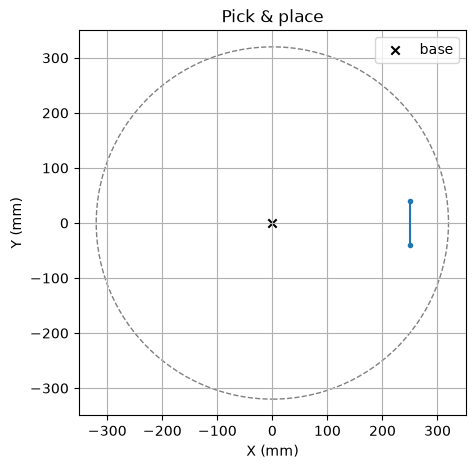

In [3]:
brazo = BrazoSimulado()
cinta = CintaSimulada()

# 1) arrancar la cinta y esperar deteccion
cinta.encender()
cinta.llega_objeto()                 # en el aula lo detecta la fotocelula

if cinta.hay_objeto():
    cinta.apagar()
    # 2) coger
    brazo.move_to(250, -40, 60)      # pre-pick
    brazo.move_to(250, -40, 0)       # pick
    brazo.gripper(cerrar=True)
    brazo.wait(500)
    brazo.move_to(250, -40, 60)      # subir
    # 3) dejar
    brazo.move_to(250, 40, 60)       # pre-place
    brazo.move_to(250, 40, 0)        # place
    brazo.gripper(cerrar=False)
    brazo.wait(500)
    brazo.move_to(250, 40, 60)       # subir
    # 4) volver a casa
    brazo.home()

print(brazo.resumen())
brazo.dibujar_trayectoria("Pick & place")

## Vuestro reto

1. Ajustad **alturas y tiempos** y justificadlos.
2. Usad **Jump** (o puntos seguros) para no chocar con la cinta.
3. **Comparad** vuestro enfoque con el de otro equipo: ¿cuál es más rápido? ¿cuál más seguro?

> **CE 4d:** la comparación de enfoques y la memoria del equipo son parte de la evaluación.

In [ ]:
# TODO: vuestra version de la secuencia (alturas, tiempos, puntos seguros)
# definid vuestros puntos y llamadas a brazo.move_to(...) y brazo.gripper(...)


## Memoria del equipo (TA3)

Redactad media página con: **decisiones de diseño**, **errores encontrados y soluciones**, y **qué cambiaríais**. Este material alimenta la recuperación del RA4.